# Experiment 06: Multi-Modal Activation Frequency-Guided Non-Mutually Exclusive Tensor Compression (Branch 2)

**Target Model**: `google/gemma-3-1b-it` (Layer 0 `model.layers[0]`, Submodules: `mlp.gate_proj` & `mlp.act_fn`)  
**Evaluation Task**: GLUE MNLI Validation Set (`validation_matched`)  

### Key Pipeline Principles:
1. **Initial Benchmarking on Unprocessed Weights**: Forward hook captures empirical activation trajectories on pristine weights ($W_{\text{orig}}$).
2. **Activation Outlier Filter**: Quarantines extreme superweights ($|x| > 3.0$ or top 1% variance) to remain uncompressed in FP32.
3. **Multi-Modal Activation Frequency Metric**: For each coordinate $c$, extracts `{coordinate: Top_K_most_frequent_activation_values[]}` representing its primary operational modes:
   $$V_c = [v_{c,1}, v_{c,2}, \dots, v_{c,M}] \in \mathbb{R}^M$$
4. **1D Absolute Difference Similarity $s(x, y) = S$**:
   $$d(v, u_k) = |v - u_k| \quad \text{(Absolute Difference)}$$
   $$s(c, k) = 1.0 - \frac{\min_{v \in V_c} |v - u_k|}{\Delta v_{\max}} \in [0, 1]$$
5. **Non-Mutually Exclusive Grouping**: Coordinates with multiple active modes can belong to multiple clusters ($C_i \cap C_j \neq \emptyset$).
6. **Non-Mutually Exclusive d-Way Tensor Construction & Tucker**: Stacks cluster weight matrices into a 3D tensor $\mathcal{T} \in \mathbb{R}^{K \times M \times D_{\text{in}}}$ and applies Tucker decomposition.
7. **Overlap-Aware Weight Composition**: Reconstructs weights via mean aggregation across active cluster memberships for shared coordinates.

In [1]:
# =====================================================================
# STEP 1: Environment Setup, Time Logging & Library Imports
# =====================================================================
import os
import sys
import time
from pathlib import Path
import math
import json
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import torch
import tensorly as tl
from tensorly.decomposition import tucker
from tensorly.tucker_tensor import tucker_to_tensor
from datasets import load_dataset
from tqdm import tqdm
from sklearn.metrics import accuracy_score
from IPython import get_ipython

# Set TensorLy PyTorch backend
tl.set_backend("pytorch")

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Minimal Time Logging
GLOBAL_NOTEBOOK_START_TIME = time.time()
NOTEBOOK_TIMINGS = []
_current_cell_start = None

ip = get_ipython()
if ip is not None:
    def _pre_cell_hook(info):
        global _current_cell_start
        _current_cell_start = time.time()

    def _post_cell_hook(result):
        global _current_cell_start
        if _current_cell_start is not None:
            elapsed = time.time() - _current_cell_start
            cumulative = time.time() - GLOBAL_NOTEBOOK_START_TIME
            cell_id = result.execution_count or len(NOTEBOOK_TIMINGS) + 1

            timing_entry = {
                "cell_id": cell_id,
                "time": round(elapsed, 3),
                "cummulative_time": round(cumulative, 3),
            }
            NOTEBOOK_TIMINGS.append(timing_entry)

            print(f"time: {elapsed:.2f}s")
            print(f"cummulative_time: {cumulative:.2f}s")

    ip.events.register("pre_run_cell", _pre_cell_hook)
    ip.events.register("post_run_cell", _post_cell_hook)

# Neural Decomp framework imports
try:
    from neural_decomp import ModelManagementInterface, DeviceMapOptions
    from neural_decomp.decomposition import decompose_svd, truncate_svd, decompose_tucker
    from neural_decomp.utils import get_device_info, save_json_metrics
    print("Loaded neural_decomp library.")
except ImportError:
    from utility import ModelManagementInterface, DeviceMapOptions
    from utility.decomposition import decompose_svd, truncate_svd, decompose_tucker
    from utility.utils import get_device_info, save_json_metrics
    print("Loaded utility library.")

device_info = get_device_info()
print(f"Device: {device_info['device_name']} | CUDA Available: {device_info['cuda_available']}")

/home/dwithun/Development/llm_compression/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded neural_decomp library.
Device: NVIDIA GeForce RTX 3070 Ti | CUDA Available: True


In [2]:
# =====================================================================
# STEP 2: Initialize Model & Tokenizer (Unprocessed Clean Baseline)
# =====================================================================
model_id = "google/gemma-3-1b-it"

mmi = ModelManagementInterface(
    model_id=model_id,
    precision=torch.float32,
    device_map=DeviceMapOptions.AUTO,
)
model = mmi.get_model()
tokenizer = mmi.get_tokenizer()

# Target Feedforward Layer 0
target_layer = model.model.layers[0]
target_submodule = target_layer.mlp.gate_proj

print(f"Target Submodule: gate_proj ({target_submodule.weight.shape[0]} x {target_submodule.weight.shape[1]})")

# Store pristine unprocessed original weights for calibration and rollbacks
W_gate_orig = target_submodule.weight.data.clone()

Loading weights: 100%|██████████| 340/340 [00:00<00:00, 356.32it/s]


Target Submodule: gate_proj (6912 x 1152)
time: 4.35s
cummulative_time: 6.26s


In [3]:
# =====================================================================
# STEP 3: Load GLUE MNLI Validation Benchmark
# =====================================================================
ds = load_dataset("nyu-mll/glue", "mnli")["validation_matched"]

label_names = ["entailment", "neutral", "contradiction"]
label_token_ids = [tokenizer.encode(" " + name, add_special_tokens=False)[0] for name in label_names]

# Sample limit for initial benchmark profiling
EVAL_SAMPLE_COUNT = 150
eval_data = ds.select(range(EVAL_SAMPLE_COUNT))

print(f"Loaded GLUE MNLI: {len(ds):,} total samples | Active Evaluation Subset: {len(eval_data):,} samples")

Loaded GLUE MNLI: 9,815 total samples | Active Evaluation Subset: 150 samples
time: 3.34s
cummulative_time: 9.61s


## Step 1: Initial Benchmarking on Unprocessed Weights & Frequency Hook (`freq_hook`)

We evaluate the pristine, uncompressed model on the benchmark samples.
Forward hook `freq_hook()` records activation values for all coordinates in Layer 0 `mlp.act_fn`:
$$\text{freq\_hook}() = \{\text{coordinate } j: \text{activation\_values over each bench sample } [v_1, v_2, \dots, v_P]\}$$

In [4]:
# =====================================================================
# STEP 4: Initial Benchmarking on Unprocessed Weights
# =====================================================================
activation_trajectories = []
current_act = None

def freq_hook(module, input_tensor, output_tensor):
    global current_act
    act = output_tensor[0] if isinstance(output_tensor, tuple) else output_tensor
    current_act = act.detach().cpu()

h = target_layer.mlp.act_fn.register_forward_hook(freq_hook)

predictions = []
ground_truth = []

model.eval()
with torch.no_grad():
    for sample in tqdm(eval_data, desc="Initial Benchmarking on Unprocessed Weights"):
        prompt = (
            f"<start_of_turn>user\n"
            f"Premise: {sample['premise']}\n"
            f"Hypothesis: {sample['hypothesis']}\n"
            f"Determine if the relationship between the 'Premise' and 'Hypothesis' is 'entailment', 'neutral' or 'contradiction.'\n"
            f"Answer with one word\n"
            f"<start_of_turn>model\n"
        )
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
        outputs = model(**inputs)

        # Mean-pool over sequence length to obtain 1D activation vector per sample: [6912]
        if current_act is not None:
            pooled = current_act.squeeze(0).mean(dim=0).numpy()
            activation_trajectories.append(pooled)

        next_token_logits = outputs.logits[0, -1, :]
        candidate_logits = next_token_logits[label_token_ids]
        pred_label = torch.argmax(candidate_logits).item()

        predictions.append(pred_label)
        ground_truth.append(sample["label"])

h.remove()

# Raw activation matrix on unprocessed weights: [num_samples, 6912]
acts_matrix = np.stack(activation_trajectories)

baseline_accuracy = accuracy_score(ground_truth, predictions)
print(f"\nUncompressed Baseline Accuracy: {baseline_accuracy * 100:.2f}%")
print(f"Captured Activation Trajectory Matrix: {acts_matrix.shape}")

Initial Benchmarking on Unprocessed Weights: 100%|██████████| 150/150 [00:05<00:00, 25.12it/s]


Uncompressed Baseline Accuracy: 50.67%
Captured Activation Trajectory Matrix: (150, 6912)
time: 5.98s
cummulative_time: 15.60s


## Step 2: Activation Outlier Filter & Multi-Modal Frequent Values Extraction (Branch 2)

1. **Outlier Filter**: Separates extreme superweights ($|x| > 3.0$ or top 1% variance) from normal activation values. Superweights remain quarantined in FP32.
2. **Multi-Modal Extraction (Branch 2)**: For each coordinate $c$, extracts:
   $$\{c: \text{Top\_K\_most\_frequent\_activation\_values}[]\}$$
   representing the top-$M$ most frequent distinct activation levels (e.g. $M=3$) observed across the calibration benchmark.

In [5]:
# =====================================================================
# STEP 5: Outlier Filter (Superweights) & Multi-Modal Value Extraction
# =====================================================================
num_samples, total_coords = acts_matrix.shape

# 1. Activation Outlier Filter: Identify extreme superweights
max_magnitudes = np.max(np.abs(acts_matrix), axis=0)
variances = np.var(acts_matrix, axis=0)

OUTLIER_THRESHOLD = 3.0
superweight_mask = (max_magnitudes > OUTLIER_THRESHOLD) | (variances >= np.quantile(variances, 0.99))
superweight_indices = np.where(superweight_mask)[0]

# Dead / Inactive coordinates (< 0.05 on > 90% of samples)
inactive_mask = (np.mean(np.abs(acts_matrix) < 0.05, axis=0) > 0.90) & (~superweight_mask)
inactive_indices = np.where(inactive_mask)[0]

# Normal active coordinates to be compressed
normal_active_mask = (~superweight_mask) & (~inactive_mask)
normal_active_indices = np.where(normal_active_mask)[0]

print(f"Total Coordinates:           {total_coords:,}")
print(f"Superweight Coordinates:     {len(superweight_indices):,} ({len(superweight_indices)/total_coords*100:.1f}%) [Quarantined FP32]")
print(f"Inactive Coordinates:        {len(inactive_indices):,} ({len(inactive_indices)/total_coords*100:.1f}%)")
print(f"Normal Active Coordinates:   {len(normal_active_indices):,} ({len(normal_active_indices)/total_coords*100:.1f}%) [Target for Tucker]")

# 2. Extract Multi-Modal Top-K Frequent Activation Values (Branch 2)
# Round activation values to 1 decimal place to group values into discrete operational regimes
TOP_K_MODES = 3
rounded_acts = np.round(acts_matrix[:, normal_active_indices], decimals=1)

coord_top_modes = {}  # {normal_active_idx: list of top_K frequent values}
all_modes_collected = []

for idx_in_active in range(len(normal_active_indices)):
    vals, counts = np.unique(rounded_acts[:, idx_in_active], return_counts=True)
    sorted_order = np.argsort(-counts)
    top_modes = vals[sorted_order[:TOP_K_MODES]].tolist()
    coord_top_modes[idx_in_active] = top_modes
    all_modes_collected.extend(top_modes)

all_modes_collected = np.array(all_modes_collected)
print(f"Extracted Top-{TOP_K_MODES} Frequent Modes for {len(normal_active_indices):,} normal active coordinates.")
print(f"Total Mode Values Profiled: {len(all_modes_collected):,}")
print(f"Mode Value Range: min = {all_modes_collected.min():.2f}, max = {all_modes_collected.max():.2f}, mean = {all_modes_collected.mean():.2f}")

Total Coordinates:           6,912
Superweight Coordinates:     71 (1.0%) [Quarantined FP32]
Inactive Coordinates:        1,315 (19.0%)
Normal Active Coordinates:   5,526 (79.9%) [Target for Tucker]
Extracted Top-3 Frequent Modes for 5,526 normal active coordinates.
Total Mode Values Profiled: 14,196
Mode Value Range: min = -0.10, max = 2.90, mean = 0.14
time: 0.07s
cummulative_time: 15.68s


## Step 3: Similarity Indexing via 1D Absolute Difference & Non-Mutually Exclusive Grouping

Because differentiating is 1-dimensional, the distance between any coordinate mode and cluster reference anchor $u_k$ is:
$$d(c, k) = \min_{v \in V_c} |v - u_k|$$
The similarity index $s(c, k)$ is:
$$s(c, k) = 1.0 - \frac{d(c, k)}{\Delta v_{\max}} \in [0, 1]$$

Coordinates that exhibit multiple active modes can belong to multiple clusters, creating **non-mutually exclusive coordinate groups** ($C_i \cap C_j \neq \emptyset$).

Cluster    | Anchor   | Size   | Max Abs Diff   | Mean Sim S
-----------------------------------------------------------------
Cluster 0   |  -0.10   | 400    |       0.00   |   1.0000
Cluster 1   |   0.00   | 400    |       0.00   |   1.0000
Cluster 2   |  -0.00   | 400    |       0.00   |   1.0000
Cluster 3   |   0.10   | 400    |       0.00   |   1.0000
Cluster 4   |   0.10   | 400    |       0.00   |   1.0000
Cluster 5   |   0.70   | 400    |       0.40   |   0.8960
-----------------------------------------------------------------
Total Cluster Slots Allocated:      2,400
Unique Active Coordinates Covered:  1,054
Average Cluster Multiplicity:       2.28 clusters/coord
Overlap Distribution:
  In exactly 1 cluster(s): 462 coords (43.8%)
  In exactly 2 cluster(s): 146 coords (13.9%)
  In exactly 3 cluster(s): 237 coords (22.5%)
  In exactly 4 cluster(s): 110 coords (10.4%)
  In exactly 5 cluster(s): 99 coords (9.4%)


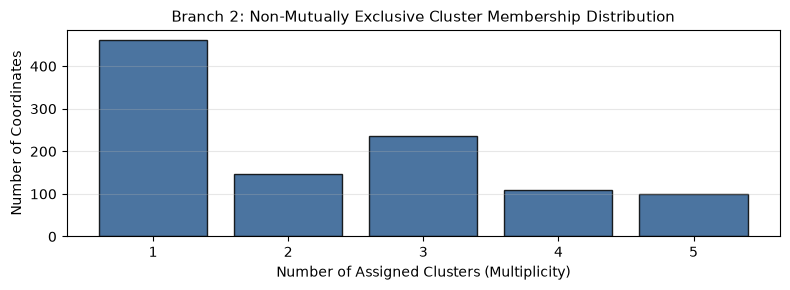

time: 0.12s
cummulative_time: 15.81s


In [6]:
# =====================================================================
# STEP 6: Non-Mutually Exclusive Coordinate Grouping & Overlap Analysis
# =====================================================================
NUM_CLUSTERS = 6
COORDS_PER_CLUSTER = 400

# Reference cluster anchor levels across empirical activation span
val_min, val_max = all_modes_collected.min(), all_modes_collected.max()
val_span = max(val_max - val_min, 1e-6)

cluster_anchors = np.quantile(all_modes_collected, np.linspace(0.05, 0.95, NUM_CLUSTERS))

# Compute distance of each normal active coordinate to each cluster anchor
num_normal = len(normal_active_indices)
dist_matrix = np.zeros((NUM_CLUSTERS, num_normal))

for k, anchor in enumerate(cluster_anchors):
    for idx_in_active in range(num_normal):
        modes = coord_top_modes[idx_in_active]
        # 1D Absolute difference to closest mode
        min_abs_diff = min(abs(v - anchor) for v in modes)
        dist_matrix[k, idx_in_active] = min_abs_diff

clusters_dict = {}  # {k: array of global coordinate indices}
cluster_local_dict = {}

print(f"{'Cluster':<10} | {'Anchor':<8} | {'Size':<6} | {'Max Abs Diff':<14} | {'Mean Sim S':<10}")
print("-" * 65)

for k in range(NUM_CLUSTERS):
    # Sort coordinates by distance to anchor k
    ranked_local = np.argsort(dist_matrix[k])[:COORDS_PER_CLUSTER]
    cluster_local_dict[k] = ranked_local
    clusters_dict[k] = normal_active_indices[ranked_local]
    
    max_diff = dist_matrix[k, ranked_local].max()
    mean_sim = 1.0 - (dist_matrix[k, ranked_local].mean() / val_span)
    print(f"Cluster {k:<3} | {cluster_anchors[k]:>6.2f}   | {COORDS_PER_CLUSTER:<6} | {max_diff:>10.2f}   | {mean_sim:>8.4f}")

print("-" * 65)

# Overlap Statistics
all_assigned_coords = np.concatenate([clusters_dict[k] for k in range(NUM_CLUSTERS)])
unique_assigned_coords, counts = np.unique(all_assigned_coords, return_counts=True)
count_dist = Counter(counts)

print(f"Total Cluster Slots Allocated:      {len(all_assigned_coords):,}")
print(f"Unique Active Coordinates Covered:  {len(unique_assigned_coords):,}")
print(f"Average Cluster Multiplicity:       {len(all_assigned_coords) / len(unique_assigned_coords):.2f} clusters/coord")
print(f"Overlap Distribution:")
for multiplicity in sorted(count_dist.keys()):
    n_coords = count_dist[multiplicity]
    pct = (n_coords / len(unique_assigned_coords)) * 100.0
    print(f"  In exactly {multiplicity} cluster(s): {n_coords:,} coords ({pct:.1f}%)")

# Overlap Multiplicity Visualization
plt.figure(figsize=(8, 3))
plt.bar(list(count_dist.keys()), list(count_dist.values()), color="#2b5c8f", edgecolor="black", alpha=0.85)
plt.title("Branch 2: Non-Mutually Exclusive Cluster Membership Distribution", fontsize=11)
plt.xlabel("Number of Assigned Clusters (Multiplicity)")
plt.ylabel("Number of Coordinates")
plt.xticks(sorted(count_dist.keys()))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Step 4: Create Non-Mutually Exclusive $d$-Way Tensor $\mathcal{T}$ & Apply Tucker Decomposition

We extract weight slices $W_k = W_{\text{gate}}[C_k, :] \in \mathbb{R}^{400 \times 1152}$ for each non-mutually exclusive cluster $k$.
We stack all $N=6$ slices into a **3D tensor** $\mathcal{T} \in \mathbb{R}^{6 \times 400 \times 1152}$:
$$\text{Tucker}(\mathcal{T}) = \mathcal{S} \times_1 A \times_2 B \times_3 C$$
Shared multi-modal neurons appear across multiple slices of $\mathcal{T}$, capturing their representation across distinct operational regimes.

In [7]:
# =====================================================================
# STEP 7: Assemble Non-Mutually Exclusive Tensor T & Run Tucker
# =====================================================================
D_IN = target_submodule.weight.shape[1]  # 1152

cluster_weight_slices = []
for k in range(NUM_CLUSTERS):
    W_k = W_gate_orig[clusters_dict[k], :].float().cpu()
    cluster_weight_slices.append(W_k)

# Stacked 3D Tensor T: [N=6, M=400, D=1152]
T = torch.stack(cluster_weight_slices, dim=0)
print(f"Stacked Non-Mutually Exclusive 3D Tensor T: {list(T.shape)} ({T.numel():,} parameters)")

W_stacked_orig = T.reshape(-1, D_IN)

tucker_configs = [
    {"label": "Tucker Balanced",   "ranks": [4, 250, 800]},
    {"label": "Tucker Moderate",   "ranks": [4, 180, 600]},
    {"label": "Tucker Aggressive", "ranks": [3, 120, 450]},
]

decomp_results = {}

for cfg in tucker_configs:
    ranks = cfg["ranks"]
    core, factors = tucker(T, rank=ranks, init='svd')
    
    # Reconstruct 3D Tensor
    T_recon = tucker_to_tensor((core, factors))
    W_recon_stacked = T_recon.reshape(-1, D_IN)
    
    # Relative Frobenius reconstruction error on stacked tensor
    rel_error = (torch.norm(W_stacked_orig - W_recon_stacked) / torch.norm(W_stacked_orig)).item()
    
    # Parameter accounting: Core + Factor Matrices
    core_params = core.numel()
    factor_params = sum(f.numel() for f in factors)
    total_compressed = core_params + factor_params
    orig_params = T.numel()
    comp_ratio = orig_params / total_compressed
    eliminated_pct = (1.0 - total_compressed / orig_params) * 100.0
    
    print(f"\n{cfg['label']} (Ranks {ranks}):")
    print(f"  Reconstruction Error: {rel_error * 100:.2f}%")
    print(f"  Core Parameters:      {core_params:,}")
    print(f"  Factor Parameters:    {factor_params:,}")
    print(f"  Total Compressed:     {total_compressed:,} vs Original {orig_params:,} ({comp_ratio:.2f}x)")
    print(f"  Parameters Cut:       {eliminated_pct:.2f}%")
    
    decomp_results[cfg["label"]] = {
        "ranks": ranks,
        "T_recon": T_recon,
        "rel_error": rel_error,
        "compression_ratio": comp_ratio,
        "eliminated_pct": eliminated_pct,
        "total_compressed": total_compressed,
    }

Stacked Non-Mutually Exclusive 3D Tensor T: [6, 400, 1152] (2,764,800 parameters)

Tucker Balanced (Ranks [4, 250, 800]):
  Reconstruction Error: 48.68%
  Core Parameters:      800,000
  Factor Parameters:    1,021,624
  Total Compressed:     1,821,624 vs Original 2,764,800 (1.52x)
  Parameters Cut:       34.11%

Tucker Moderate (Ranks [4, 180, 600]):
  Reconstruction Error: 62.79%
  Core Parameters:      432,000
  Factor Parameters:    763,224
  Total Compressed:     1,195,224 vs Original 2,764,800 (2.31x)
  Parameters Cut:       56.77%

Tucker Aggressive (Ranks [3, 120, 450]):
  Reconstruction Error: 77.26%
  Core Parameters:      162,000
  Factor Parameters:    566,418
  Total Compressed:     728,418 vs Original 2,764,800 (3.80x)
  Parameters Cut:       73.65%
time: 2.38s
cummulative_time: 18.20s


## Step 5: Overlap-Aware Weight Reconstruction & Live Model Injection

When reconstructing weights from non-mutually exclusive cluster slices:
For coordinates belonging to multiple clusters $\mathcal{K}_c = \{k : c \in C_k\}$, we compose the reconstructed rows via **mean aggregation**:
$$\hat{W}[c, :] = \frac{1}{|\mathcal{K}_c|} \sum_{k \in \mathcal{K}_c} \hat{W}_k[\text{local\_idx}(c, k), :]$$
**Quarantined superweights remain in pristine FP32.**

In [8]:
# =====================================================================
# STEP 8: Overlap-Aware Composition, Injection & Benchmark Accuracy
# =====================================================================
benchmark_eval_results = []

for label, res in decomp_results.items():
    T_recon = res["T_recon"]
    
    # Reconstruct weight matrix with overlap aggregation
    W_reconstructed = W_gate_orig.clone().float().cpu()
    weight_accum = torch.zeros_like(W_gate_orig, dtype=torch.float32, device="cpu")
    membership_counts = torch.zeros(W_gate_orig.shape[0], dtype=torch.float32, device="cpu")
    
    for k in range(NUM_CLUSTERS):
        coords_tensor = torch.tensor(clusters_dict[k], dtype=torch.long)
        W_k_recon = T_recon[k].float().cpu()
        weight_accum.index_add_(0, coords_tensor, W_k_recon)
        membership_counts.index_add_(0, coords_tensor, torch.ones(len(coords_tensor), dtype=torch.float32))
        
    compressed_mask = membership_counts > 0
    W_reconstructed[compressed_mask] = weight_accum[compressed_mask] / membership_counts[compressed_mask].unsqueeze(1)
    
    # Ensure superweights strictly preserved in pristine FP32
    W_reconstructed[superweight_indices] = W_gate_orig[superweight_indices].float().cpu()
    
    # Inject into live model
    target_submodule.weight.data = W_reconstructed.to(device=model.device, dtype=target_submodule.weight.dtype)
    
    print(f"\nEvaluating {label} on MNLI...")
    preds, gts = [], []
    model.eval()
    with torch.no_grad():
        for sample in tqdm(eval_data, desc=f"Evaluating {label}"):
            prompt = (
                f"<start_of_turn>user\n"
                f"Premise: {sample['premise']}\n"
                f"Hypothesis: {sample['hypothesis']}\n"
                f"Determine if the relationship between the 'Premise' and 'Hypothesis' is 'entailment', 'neutral' or 'contradiction.'\n"
                f"Answer with one word\n"
                f"<start_of_turn>model\n"
            )
            inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
            outputs = model(**inputs)
            next_token_logits = outputs.logits[0, -1, :]
            pred_label = torch.argmax(next_token_logits[label_token_ids]).item()
            preds.append(pred_label)
            gts.append(sample["label"])
            
    acc = accuracy_score(gts, preds)
    delta = acc - baseline_accuracy
    print(f"  Accuracy: {acc * 100:.2f}% (Δ vs Baseline: {delta * 100:+.2f}%)")
    
    benchmark_eval_results.append({
        "Variant": label,
        "Ranks": str(res["ranks"]),
        "Parameters": res["total_compressed"],
        "Ratio": f"{res['compression_ratio']:.2f}x",
        "Cut (%)": f"{res['eliminated_pct']:.1f}%",
        "Recon Err (%)": f"{res['rel_error'] * 100:.2f}%",
        "Accuracy (%)": f"{acc * 100:.2f}%",
        "Delta vs Base": f"{delta * 100:+.2f}%",
    })

# Restore clean baseline
target_submodule.weight.data = W_gate_orig.clone()
print("\nBaseline weights restored.")


Evaluating Tucker Balanced on MNLI...


Evaluating Tucker Balanced: 100%|██████████| 150/150 [00:05<00:00, 27.93it/s]


  Accuracy: 50.67% (Δ vs Baseline: +0.00%)

Evaluating Tucker Moderate on MNLI...


Evaluating Tucker Moderate: 100%|██████████| 150/150 [00:05<00:00, 27.64it/s]


  Accuracy: 46.67% (Δ vs Baseline: -4.00%)

Evaluating Tucker Aggressive on MNLI...


Evaluating Tucker Aggressive: 100%|██████████| 150/150 [00:05<00:00, 27.16it/s]

  Accuracy: 43.33% (Δ vs Baseline: -7.33%)

Baseline weights restored.
time: 16.40s
cummulative_time: 34.61s


## Step 6: Summary Table, Overlap Statistics & Global Time Log

We tabulate the compression ratio, parameter reduction, reconstruction error, overlap multiplicity, and task accuracy retention for Branch 2.

In [9]:
# =====================================================================
# STEP 9: Summary Table & Artifact Export
# =====================================================================
summary_table = [
    {
        "Variant": "Baseline (Uncompressed)",
        "Ranks": "Full",
        "Parameters": T.numel(),
        "Ratio": "1.00x",
        "Cut (%)": "0.0%",
        "Recon Err (%)": "0.00%",
        "Accuracy (%)": f"{baseline_accuracy * 100:.2f}%",
        "Delta vs Base": "+0.00%",
    }
] + benchmark_eval_results

print("=" * 105)
print(f"{'Variant':<28} | {'Ranks':<16} | {'Params':<9} | {'Ratio':<6} | {'Cut %':<6} | {'Err %':<7} | {'Accuracy':<9} | {'Delta':<7}")
print("=" * 105)
for row in summary_table:
    print(f"{row['Variant']:<28} | {row['Ranks']:<16} | {row['Parameters']:<9} | {row['Ratio']:<6} | {row['Cut (%)']:<6} | {row['Recon Err (%)']:<7} | {row['Accuracy (%)']:<9} | {row['Delta vs Base']:<7}")
print("=" * 105)

# Global Notebook Timing
total_notebook_runtime = time.time() - GLOBAL_NOTEBOOK_START_TIME
print(f"cummulative_time: {total_notebook_runtime:.2f}s")

# Save export artifact
artifact_dir = Path("artifacts")
artifact_dir.mkdir(parents=True, exist_ok=True)
output_path = artifact_dir / "06_branch2_freq_results.json"

export_data = {
    "experiment": "06_freq_guided_tucker_branch2",
    "distance_metric": "1D_absolute_difference_multimodal",
    "model_id": model_id,
    "eval_samples": len(eval_data),
    "superweight_count": len(superweight_indices),
    "unique_coords_covered": len(unique_assigned_coords),
    "total_slots_allocated": len(all_assigned_coords),
    "mean_multiplicity": round(len(all_assigned_coords) / len(unique_assigned_coords), 3),
    "overlap_distribution": {int(k): int(v) for k, v in count_dist.items()},
    "baseline_accuracy": baseline_accuracy,
    "results": summary_table,
    "timing_summary": {
        "cummulative_time_sec": round(total_notebook_runtime, 3),
        "cell_timings": NOTEBOOK_TIMINGS,
    }
}

save_json_metrics(export_data, output_path)
print(f"\nBenchmark results saved to: {output_path}")

Variant                      | Ranks            | Params    | Ratio  | Cut %  | Err %   | Accuracy  | Delta  
Baseline (Uncompressed)      | Full             | 2764800   | 1.00x  | 0.0%   | 0.00%   | 50.67%    | +0.00% 
Tucker Balanced              | [4, 250, 800]    | 1821624   | 1.52x  | 34.1%  | 48.68%  | 50.67%    | +0.00% 
Tucker Moderate              | [4, 180, 600]    | 1195224   | 2.31x  | 56.8%  | 62.79%  | 46.67%    | -4.00% 
Tucker Aggressive            | [3, 120, 450]    | 728418    | 3.80x  | 73.7%  | 77.26%  | 43.33%    | -7.33% 
cummulative_time: 34.61s

Benchmark results saved to: artifacts/06_branch2_freq_results.json
time: 0.00s
cummulative_time: 34.61s
